Imports

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Create Dataset

In [14]:
np.random.seed(42)

dates = pd.date_range(start='2023-01-01', periods=365)

data = {
    'Date': dates,
    'Temperature': np.random.randint(15, 40, 365),
    'Humidity': np.random.randint(30, 90, 365),
    'Rainfall': np.random.randint(0, 20, 365),
    'Wind_Speed': np.random.randint(5, 25, 365)
}

df = pd.DataFrame(data)

# Save dataset
df.to_csv('../data/weather_data.csv', index=False)

df.head()

,Date,Temperature,Humidity,Rainfall,Wind_Speed
0,2023-01-01,21,58,0,23
1,2023-01-02,34,78,19,10
2,2023-01-03,29,75,16,5
3,2023-01-04,25,82,6,19
4,2023-01-05,22,60,12,5


Load Dataset

In [17]:
df = pd.read_csv('../data/weather_data.csv')
print("Shape:",df.shape)
df.head()

Shape: (365, 5)


,Date,Temperature,Humidity,Rainfall,Wind_Speed
0,2023-01-01,21,58,0,23
1,2023-01-02,34,78,19,10
2,2023-01-03,29,75,16,5
3,2023-01-04,25,82,6,19
4,2023-01-05,22,60,12,5


Data Understanding

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         365 non-null    object
 1   Temperature  365 non-null    int64 
 2   Humidity     365 non-null    int64 
 3   Rainfall     365 non-null    int64 
 4   Wind_Speed   365 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 14.4+ KB


In [19]:
df.describe()

,Temperature,Humidity,Rainfall,Wind_Speed
count,365.000000,365.000000,365.000000,365.000000
mean,26.569863,60.841096,9.180822,14.400000
std,7.567910,16.966741,5.825311,5.895053
min,15.000000,30.000000,0.000000,5.000000
25%,20.000000,47.000000,4.000000,9.000000
50%,26.000000,61.000000,9.000000,14.000000
75%,33.000000,76.000000,14.000000,19.000000
max,39.000000,89.000000,19.000000,24.000000


Data Cleaning & Feature Engineering

In [20]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# Extract features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(0, inplace=True)

Temperature Trend

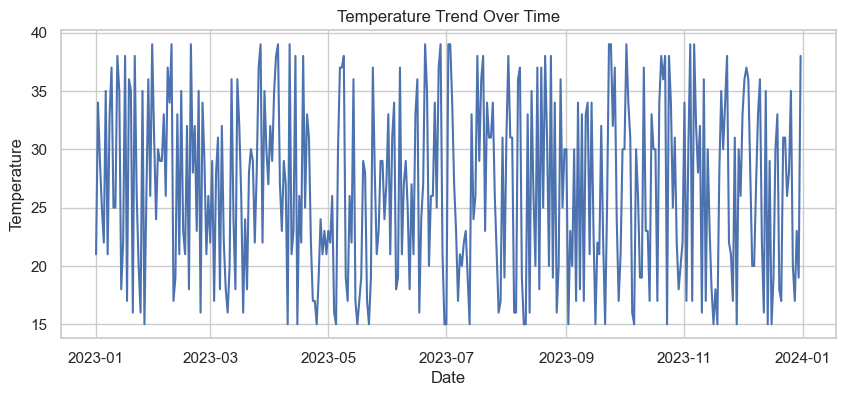

In [22]:
plt.figure(figsize=(10,4))

plt.plot(df['Date'], df['Temperature'])

plt.title("Temperature Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.savefig('../visualizations/temp_trend.png')
plt.show()

Monthly Average Temperature

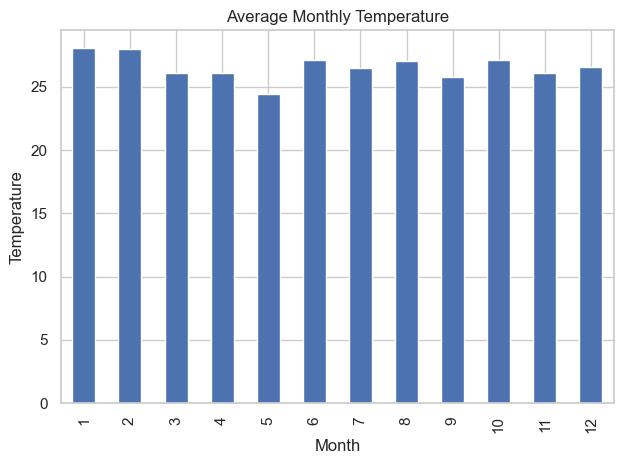

In [23]:
monthly_temp = df.groupby('Month')['Temperature'].mean()

monthly_temp.plot(kind='bar')

plt.title("Average Monthly Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")

plt.tight_layout()
plt.savefig('../visualizations/monthly_temp.png')
plt.show()

Rainfall Analysis

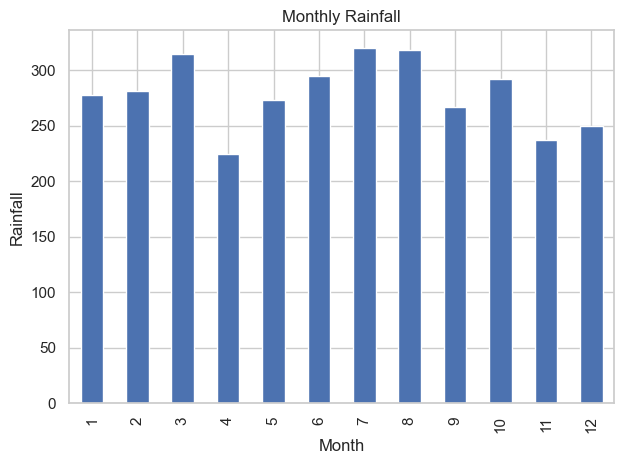

In [24]:
monthly_rain = df.groupby('Month')['Rainfall'].sum()

monthly_rain.plot(kind='bar')

plt.title("Monthly Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall")

plt.tight_layout()
plt.savefig('../visualizations/rainfall.png')
plt.show()

Humidity vs Temperature

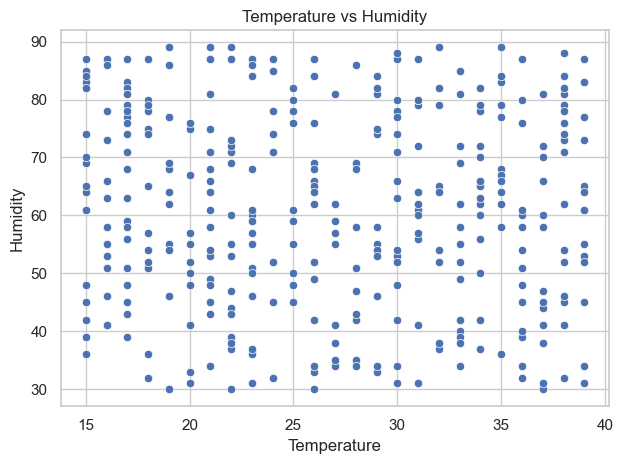

In [25]:
sns.scatterplot(x='Temperature', y='Humidity', data=df)

plt.title("Temperature vs Humidity")

plt.tight_layout()
plt.savefig('../visualizations/temp_vs_humidity.png')
plt.show()

Extreme Weather Detection

In [26]:
hot_days = df[df['Temperature'] > 35]
cold_days = df[df['Temperature'] < 18]

print("Hot Days:", len(hot_days))
print("Cold Days:", len(cold_days))

Hot Days: 60
Cold Days: 59


Correlation Analysis

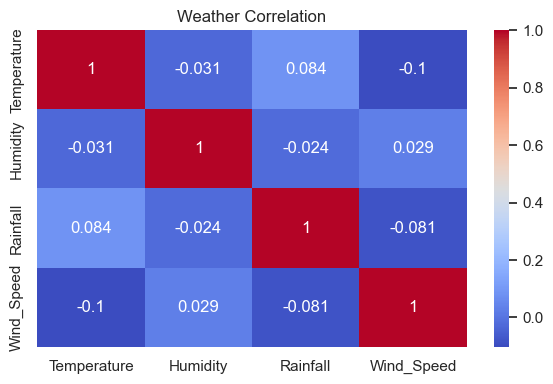

In [27]:
corr = df[['Temperature','Humidity','Rainfall','Wind_Speed']].corr()

plt.figure(figsize=(6,4))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Weather Correlation")

plt.tight_layout()
plt.savefig('../visualizations/weather_corr.png')
plt.show()

Save Report

In [29]:
df.to_csv('../reports/weather_analysis.pdf', index=False)

FINAL INSIGHTS:

1. Highest temperatures occur in summer months (May–June).
2. Rainfall is highest during monsoon months.
3. Temperature and humidity show a moderate relationship.
4. Number of extreme hot days is around 60.
5. Seasonal patterns clearly indicate temperature peaks mid-year.

RECOMMENDATIONS:

1. Prepare for heatwaves during peak summer months.
2. Improve drainage systems for heavy rainfall periods.
3. Monitor humidity levels for accurate weather prediction.
4. Plan agricultural activities based on seasonal trends.